In [366]:
import math
import random
from typing import Any, cast

import numpy as np
import pandas as pd
import seaborn as sns
from pandas import DataFrame, Series
from sklearn.metrics import accuracy_score, confusion_matrix

In [367]:
iris = cast(DataFrame, pd.read_csv("../../data/iris.csv"))

In [368]:
iris.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [369]:
iris.describe()

,sepal.length,sepal.width,petal.length,petal.width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [370]:
label = "variety"
features = ["sepal.length", "sepal.width", "petal.length", "petal.width"]

In [371]:
def shuffle_dataset(data: DataFrame) -> None:
    for i in range(len(data)):
        random_id = random.randint(0, len(data) - 1)
        data.iloc[i], data.iloc[random_id] = data.iloc[random_id], data.iloc[i]


def split_dataset(data: DataFrame, percentage: float) -> tuple[DataFrame, DataFrame]:
    assert 0 <= percentage <= 1

    take = int(len(data) * percentage)
    return data[:take], data[take:]

In [372]:
shuffle_dataset(iris)
train_data, validation_data = split_dataset(iris, 0.7)

In [373]:
X_train, y_train = train_data[features], train_data[label]
X_validation, y_validation = validation_data[features], validation_data[label]

In [374]:
def gauss(x: float, mean: float, std: float) -> float:
    exponent = ((x - mean) ** 2) / (2 * std ** 2)
    return np.exp(-exponent) / (std * math.sqrt(2 * np.pi))

In [375]:
def mean(x: Series) -> float:
    return x.sum() / x.count()


def variance(x: Series) -> float:
    nominator = ((x - mean(x)) ** 2).sum()
    return nominator / (x.count() - 1)

In [376]:
def naive_bayes_calculate_stats(data: DataFrame, labels: Series) -> DataFrame:
    stats = data.groupby(by=labels).aggregate([mean, variance])
    stats["likelihood"] = labels.value_counts(normalize=True)
    return stats


def _naive_bayes_classify_single(stats: DataFrame, data: Series) -> Any:
    results = Series(0, index=stats.index, dtype=float)

    for label in stats.index:
        probability = math.log(stats["likelihood"][label])

        for feature in data.index:
            x = data[feature]
            mean = stats.loc[label, (feature, "mean")]
            variance = stats.loc[label, (feature, "variance")]

            probability += math.log(gauss(x, mean, math.sqrt(variance)))

        results[label] = probability

    return results.idxmax()


def naive_bayes(stats: DataFrame, unclassified: DataFrame) -> Series:
    return unclassified.apply(lambda row: _naive_bayes_classify_single(stats, row), axis=1)

In [377]:
stats = naive_bayes_calculate_stats(X_train, y_train)
y_predicted = naive_bayes(stats, X_validation)

In [378]:
accuracy = accuracy_score(y_validation, y_predicted)
confusion = confusion_matrix(y_validation, y_predicted)

In [379]:
print(f"Dokładność wynosi {accuracy * 100:.2f}%")

Dokładność wynosi 93.33%


<Axes: >

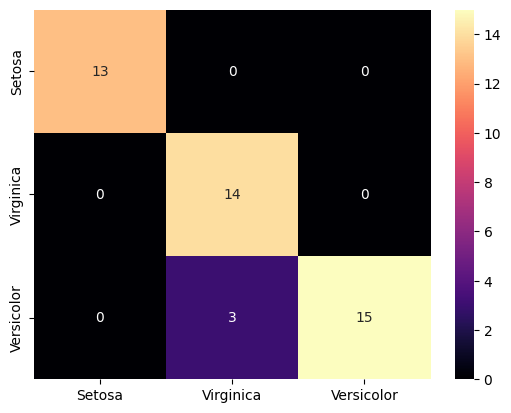

In [380]:
label_classes = iris[label].unique()
sns.heatmap(confusion, annot=True, cmap='magma', xticklabels=label_classes, yticklabels=label_classes)